# Stage 4: Validation and Fitting

## Goal:

This notebook tests wether the model-fitting procedure is meaningful before applying it to real empirical data. 

We:
1. Simulate network activity using known ground-truth values of *K* and *lambda*
2. Add measurement noise
3. Compute a synthetic empirical PLI matrix
4. Fit K and lambda by maximising Pearson correlation
5. Visualise the fit quality and parameter recovery

In [3]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from hopf_model import gaussian_initial_conditions, simulate_hopf
from network_analysis import upper_triangle_values
from signal_processing import bandpass_filter, compute_phase, compute_pli


## Hopf Network Model

We use a network of **coupled Hopf oscillators**, where:
- Each node represents a brain region (78 regions from a parcellation atlas)
- Nodes are coupled through a structural connectivity (SC) matrix *W*, derived from diffusion MRI tractography
- Each node follows a normal form Hopf bifurcation:

$$\dot{x}_i = x_i(\lambda - r_i^2) - \omega_i y_i + K \tanh\left(C \sum_j W_{ij} x_j\right)$$
$$\dot{y}_i = y_i(\lambda - r_i^2) + \omega_i x_i$$

where:
- $\lambda$ controls **local excitability** (negative → damped oscillation; positive → limit cycle)
- $K$ is the **global coupling strength**
- $\omega_i = 2\pi f_i$ is the natural frequency of node $i$ (set to the empirical peak frequency)
- $C$ is a saturation constant (fixed at 1)

The two free parameters we fit are **$K$** and **$\lambda$**.


In [5]:
# Hopf integration and initial-condition helpers are imported from src/hopf_model.py.


## Signal Processing and PLI

After simulation, node signals are:
1. **Band-pass filtered** (8–12 Hz, alpha band) using a 4th-order Butterworth filter
2. **Hilbert-transformed** to extract instantaneous phase
3. **PLI** (Phase Lag Index) is computed between all pairs of nodes:

$$\text{PLI}_{ij} = \left|\langle \text{sign}(\sin(\Delta\phi_{ij}(t))) \rangle_t\right|$$

PLI measures the asymmetry of the phase difference distribution — it is robust to volume conduction artefacts because it ignores zero-lag phase coupling.


In [6]:
# Signal-processing and matrix helpers are imported from src/signal_processing.py
# and src/network_analysis.py.


## Phase 1 — Synthetic Validation

### Step 1: Small synthetic test network

We first build a small 6-node synthetic network with a known connectivity structure to test the simulation pipeline before scaling to 78 regions.


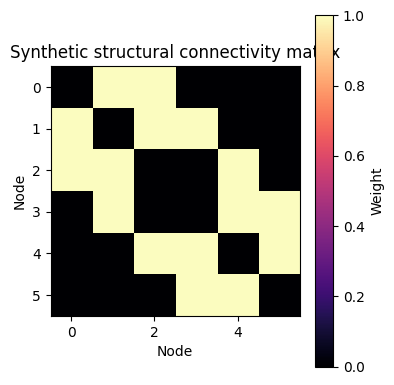

In [7]:
# -----------------------------
# Small synthetic test network
# -----------------------------

N = 6

W = np.array([
    [0, 1, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 0],
    [1, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1, 1],
    [0, 0, 1, 1, 0, 1],
    [0, 0, 0, 1, 1, 0],
], dtype=float)

W = W / W.max()

omega_hz = 10.0
omega = 2 * np.pi * omega_hz * np.ones(N)

fs = 250
t_total = 20.0
t_discard = 5.0
C = 1.0

z0 = gaussian_initial_conditions(N, rng=42)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(W, cmap="magma")
ax.set_title("Synthetic structural connectivity matrix")
ax.set_xlabel("Node")
ax.set_ylabel("Node")
plt.colorbar(im, ax=ax, label="Weight")
fig.tight_layout()

### Step 2: Generate synthetic empirical PLI

We simulate the model with **known ground-truth parameters** ($K_{\text{true}}$, $\lambda_{\text{true}}$), optionally add noise, and compute the resulting PLI matrix. This will serve as our "empirical" target for the fitting step.


In [8]:
# -----------------------------
# Generate synthetic empirical PLI
# -----------------------------

def generate_synthetic_empirical_pli(N, W, K_true, lam_true, C, omega, z0,
                                     t_total=20.0, t_discard=5.0, fs=250,
                                     noise_std=0.05, f_lo=8.0, f_hi=12.0,
                                     rng=12345):
    """Generate synthetic empirical PLI with explicit deterministic noise."""
    t, x, y = simulate_hopf(
        N=N, W=W, K=K_true, lam=lam_true, C=C,
        omega=omega, z0=z0,
        t_total=t_total, t_discard=t_discard, fs=fs,
        rtol=1e-6, atol=1e-8,
    )

    rng = np.random.default_rng(rng)
    noisy_x = x + noise_std * rng.standard_normal(x.shape)
    filtered_x = bandpass_filter(noisy_x, fs=fs, low=f_lo, high=f_hi)
    phases = compute_phase(noisy_x, fs=fs, low=f_lo, high=f_hi)
    pli_emp = compute_pli(phases)

    return t, noisy_x, filtered_x, pli_emp


### Step 3: Run the synthetic simulation

We set the ground-truth parameters and generate the synthetic empirical PLI. The resulting signal and PLI matrix are visualised below.


Ground-truth parameters: K = 0.800, lambda = 1.000


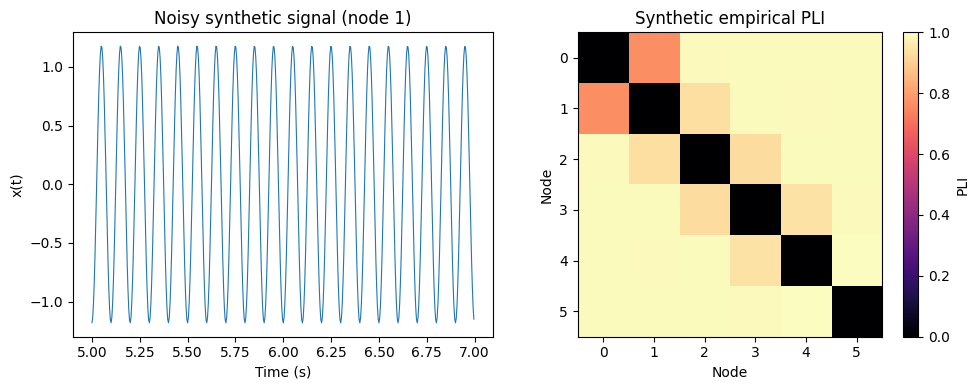

In [12]:
K_true = 0.8
lam_true = 1.0

t_emp, x_emp_noisy, x_emp_filt, pli_emp = generate_synthetic_empirical_pli(
    N=N, W=W, K_true=K_true, lam_true=lam_true, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
    noise_std=0,
)

print(f"Ground-truth parameters: K = {K_true:.3f}, lambda = {lam_true:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_emp[:500], x_emp_noisy[0, :500], lw=0.8)
axes[0].set_title("Noisy synthetic signal (node 1)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x(t)")

im = axes[1].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[1].set_title("Synthetic empirical PLI")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

plt.colorbar(im, ax=axes[1], label="PLI")
fig.tight_layout()

### Step 4: Grid search to fit *K* and *λ*

We perform an exhaustive grid search over a range of *K* and *λ* values. For each parameter pair:
1. Simulate the network
2. Filter and compute PLI
3. Measure Pearson correlation with the synthetic empirical PLI

The parameter pair achieving the highest correlation is taken as the fitted estimate.


In [13]:
# -----------------------------
# Fit K and lambda by grid search
# -----------------------------

def fit_k_lambda_grid(N, W, pli_emp, K_values, lam_values, C, omega, z0,
                      t_total=20.0, t_discard=5.0, fs=250,
                      f_lo=8.0, f_hi=12.0):
    """Grid search over K and lambda using shared Hopf/PLI helpers."""
    emp_vals = upper_triangle_values(pli_emp)

    corr_map = np.zeros((len(K_values), len(lam_values)))
    best_corr = -np.inf
    best_params = None
    best_pli = None

    for i, K in enumerate(K_values):
        for j, lam in enumerate(lam_values):
            t, x, y = simulate_hopf(
                N=N, W=W, K=K, lam=lam, C=C,
                omega=omega, z0=z0,
                t_total=t_total, t_discard=t_discard, fs=fs,
                rtol=1e-6, atol=1e-8,
            )

            phases = compute_phase(x, fs=fs, low=f_lo, high=f_hi)
            pli_sim = compute_pli(phases)
            sim_vals = upper_triangle_values(pli_sim)
            corr, _ = pearsonr(emp_vals, sim_vals)

            corr_map[i, j] = corr

            if corr > best_corr:
                best_corr = corr
                best_params = (K, lam)
                best_pli = pli_sim.copy()

    return corr_map, best_corr, best_params, best_pli


### Step 5: Run the grid search

The recovered parameters should be close to the ground-truth values if the fitting procedure is working correctly.


In [14]:
K_values = np.linspace(0.1, 1.5, 15)
lam_values = np.linspace(-0.5, 2.0, 15)

corr_map, best_corr, best_params, best_pli = fit_k_lambda_grid(
    N=N, W=W, pli_emp=pli_emp,
    K_values=K_values, lam_values=lam_values,
    C=C, omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

print(f"True parameters:      K = {K_true:.3f}, lambda = {lam_true:.3f}")
print(f"Recovered parameters: K = {best_params[0]:.3f}, lambda = {best_params[1]:.3f}")
print(f"Best correlation:     r = {best_corr:.3f}")

True parameters:      K = 0.800, lambda = 1.000
Recovered parameters: K = 0.900, lambda = 1.286
Best correlation:     r = 0.998


### Step 6: Visualise the correlation landscape

The heatmap below shows the Pearson correlation as a function of *K* (y-axis) and *λ* (x-axis). A well-posed fitting problem should produce a clear, unimodal peak.

- ⚪ White circle: ground-truth parameter location
- ✖ Red cross: recovered (best-fit) location


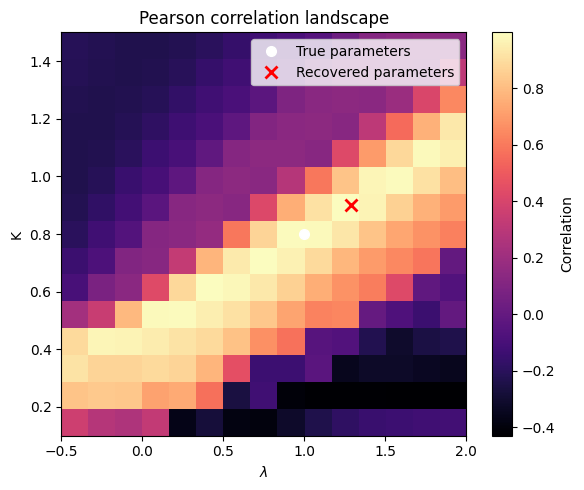

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    corr_map,
    origin="lower",
    aspect="auto",
    extent=[lam_values[0], lam_values[-1], K_values[0], K_values[-1]],
    cmap="magma",
)

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("K")
ax.set_title("Pearson correlation landscape")

ax.plot(lam_true, K_true, "wo", ms=7, label="True parameters")
ax.plot(best_params[1], best_params[0], "rx", ms=8, mew=2, label="Recovered parameters")
ax.legend()

plt.colorbar(im, ax=ax, label="Correlation")
fig.tight_layout()

### Step 7: Scatter plots — simulated vs empirical PLI

Each point represents one pair of brain regions. The x-axis shows the synthetic empirical PLI value; the y-axis shows the simulated PLI for a given parameter combination.

A good fit produces points along the diagonal (slope ≈ 1, high Pearson r).


In [17]:
# -----------------------------
# Scatter plots: simulated vs empirical PLI
# -----------------------------

def plot_pli_scatter(pli_emp, pli_sim, title):
    emp_vals = upper_triangle_values(pli_emp)
    sim_vals = upper_triangle_values(pli_sim)
    r, _ = pearsonr(emp_vals, sim_vals)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(emp_vals, sim_vals, alpha=0.7)
    ax.set_xlabel("Synthetic empirical PLI")
    ax.set_ylabel("Simulated PLI")
    ax.set_title(f"{title}\nPearson r = {r:.3f}")

    lo = min(emp_vals.min(), sim_vals.min())
    hi = max(emp_vals.max(), sim_vals.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)

    fig.tight_layout()

**Best-fit parameters:** highest correlation recovered by grid search.


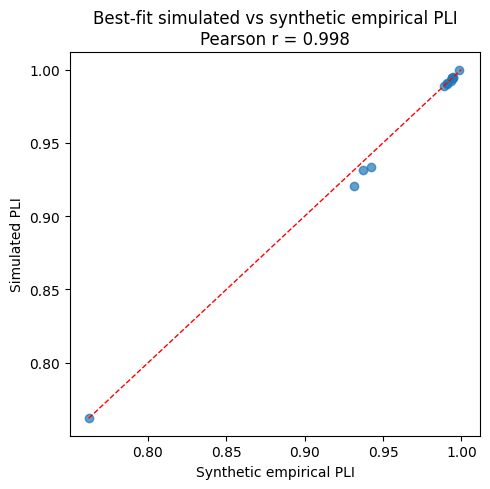

In [18]:
plot_pli_scatter(
    pli_emp, best_pli,
    title="Best-fit simulated vs synthetic empirical PLI"
)

**Poor-fit parameters:** deliberately chosen from the edge of the parameter grid to illustrate what a bad fit looks like.


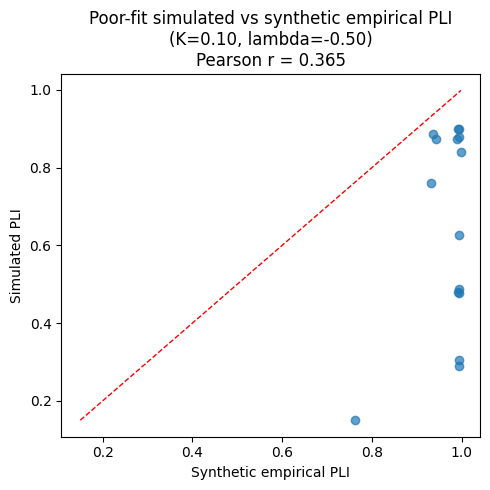

In [19]:
K_bad = K_values[0]
lam_bad = lam_values[0]

t_bad, x_bad, y_bad = simulate_hopf(
    N=N, W=W, K=K_bad, lam=lam_bad, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

x_bad_filt = bandpass_filter(x_bad, fs=fs, low=8.0, high=12.0)
pli_bad = compute_pli(compute_phase(x_bad, fs=fs, low=8.0, high=12.0))

plot_pli_scatter(
    pli_emp, pli_bad,
    title=f"Poor-fit simulated vs synthetic empirical PLI\n(K={K_bad:.2f}, lambda={lam_bad:.2f})"
)

### Step 8: PLI matrix comparison

Side-by-side visualisation of the synthetic empirical PLI, the best-fit simulated PLI, and a poor-fit simulated PLI.

> **Phase 1 complete.** If the recovered parameters are close to ground truth and the correlation landscape shows a clear peak, the fitting procedure is valid. We can now apply it to real empirical data.


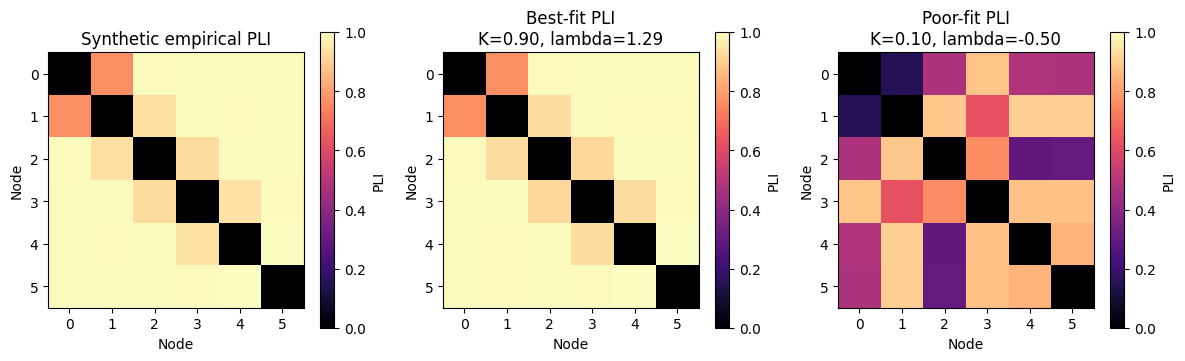

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[0].set_title("Synthetic empirical PLI")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")

im1 = axes[1].imshow(best_pli, vmin=0, vmax=1, cmap="magma")
axes[1].set_title(f"Best-fit PLI\nK={best_params[0]:.2f}, lambda={best_params[1]:.2f}")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

im2 = axes[2].imshow(pli_bad, vmin=0, vmax=1, cmap="magma")
axes[2].set_title(f"Poor-fit PLI\nK={K_bad:.2f}, lambda={lam_bad:.2f}")
axes[2].set_xlabel("Node")
axes[2].set_ylabel("Node")

plt.colorbar(im0, ax=axes[0], shrink=0.8, label="PLI")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="PLI")
plt.colorbar(im2, ax=axes[2], shrink=0.8, label="PLI")
plt.tight_layout()

---

## Phase 2 — Fitting to Real Empirical MEG Data

Now that the fitting procedure has been validated synthetically, we apply it to the real MEG-derived PLI matrices from:

- `control_PLI_raw.csv` — group-averaged PLI matrix for **healthy controls** (78 × 78)
- `glioma_PLI_raw.csv` — group-averaged PLI matrix for **glioma patients** (78 × 78)
- `structural_connectivity_matrix.csv` — structural connectivity matrix *W* (78 × 78, from diffusion MRI)
- `exp_frequencies.csv` — empirical peak frequencies per region, used to set node natural frequencies *ω*

### Procedure

For **each group** independently:
1. Load the empirical PLI matrix as the fitting target
2. Set node natural frequencies from `exp_frequencies.csv` (group mean per region)
3. Load the structural connectivity matrix *W*
4. Run the grid search over *K* and *λ*
5. Report the best-fit parameters and the Pearson correlation at the best fit
6. Visualise the correlation landscape and the PLI matrix comparison

### Scientific interpretation

| Parameter | Control interpretation | Glioma interpretation |
|-----------|------------------------|----------------------|
| $K$ (coupling) | Baseline global synchronisation | May be elevated due to tumour-driven network reorganisation |
| $\lambda$ (excitability) | Normal resting excitability | May be shifted by local hyperexcitability near the tumour |

Differences in fitted parameters between groups will reflect how glioma alters the **dynamical operating point** of the whole-brain network.
